In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATASET_PATH = r"C:\Apple_Custard_Classification"

IMAGE_SIZE = (256, 256)

class_names = [
    "apple",
    "custard apple"
]

images = []
labels = []

for label, class_name in enumerate(class_names):

    folder_path = os.path.join(
        DATASET_PATH,
        class_name
    )

    print("Reading:", folder_path)

    for filename in os.listdir(folder_path):

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        ):

            image_path = os.path.join(
                folder_path,
                filename
            )

            image = cv2.imread(image_path)

            if image is not None:

                image = cv2.resize(
                    image,
                    IMAGE_SIZE
                )

                images.append(image)
                labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("\n==============================")
print("DATASET INFORMATION")
print("==============================")

print("Total images:", len(images))
print("Image shape:", images.shape)
print("Labels shape:", labels.shape)

for i, name in enumerate(class_names):
    print(
        name,
        ":",
        np.sum(labels == i),
        "images"
    )

Reading: C:\Apple_Custard_Classification\apple
Reading: C:\Apple_Custard_Classification\custard apple

DATASET INFORMATION
Total images: 2277
Image shape: (2277, 256, 256, 3)
Labels shape: (2277,)
apple : 1203 images
custard apple : 1074 images


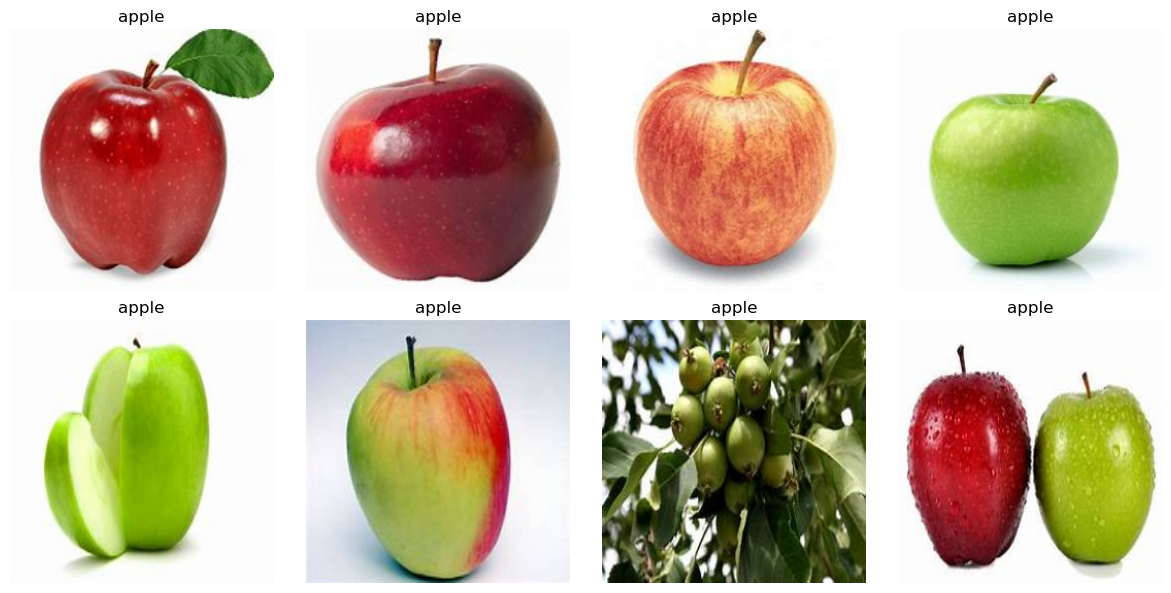

In [2]:
plt.figure(figsize=(12, 6))

for i in range(min(8, len(images))):

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    )

    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [3]:
sift = cv2.SIFT_create(
    nfeatures=300
)

sift_descriptors = []

for i, image in enumerate(images):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    keypoints, descriptors = sift.detectAndCompute(
        gray,
        None
    )

    if descriptors is None:
        descriptors = np.empty(
            (0, 128),
            dtype=np.float32
        )

    sift_descriptors.append(descriptors)

print("SIFT feature extraction completed.")

print(
    "Number of SIFT descriptors in first image:",
    len(sift_descriptors[0])
)

SIFT feature extraction completed.
Number of SIFT descriptors in first image: 165


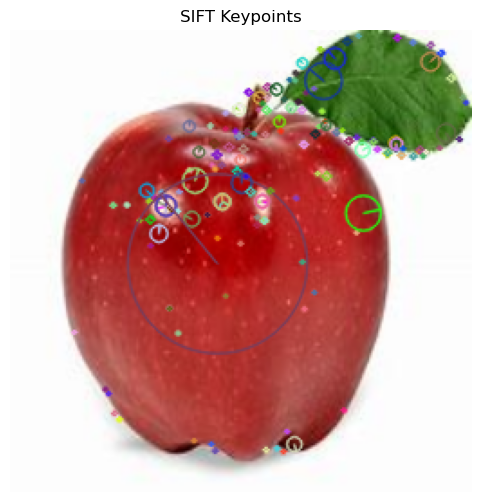

Number of keypoints: 165


In [4]:
sample_image = images[0]

gray = cv2.cvtColor(
    sample_image,
    cv2.COLOR_BGR2GRAY
)

keypoints, descriptors = sift.detectAndCompute(
    gray,
    None
)

sift_image = cv2.drawKeypoints(
    sample_image,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(8, 6))

plt.imshow(
    cv2.cvtColor(
        sift_image,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("SIFT Keypoints")
plt.axis("off")
plt.show()

print("Number of keypoints:", len(keypoints))

In [5]:
all_descriptors = []

for descriptors in sift_descriptors:

    if len(descriptors) > 0:
        all_descriptors.append(descriptors)

all_descriptors = np.vstack(
    all_descriptors
)

print(
    "Total SIFT descriptors:",
    len(all_descriptors)
)

print(
    "SIFT descriptor dimension:",
    all_descriptors.shape[1]
)

Total SIFT descriptors: 534120
SIFT descriptor dimension: 128


In [6]:
from sklearn.cluster import MiniBatchKMeans

K = 50

MAX_DESCRIPTORS = 50000

if len(all_descriptors) > MAX_DESCRIPTORS:

    rng = np.random.default_rng(42)

    indices = rng.choice(
        len(all_descriptors),
        MAX_DESCRIPTORS,
        replace=False
    )

    training_descriptors = all_descriptors[
        indices
    ]

else:

    training_descriptors = all_descriptors

print(
    "Descriptors used for K-Means:",
    len(training_descriptors)
)

kmeans = MiniBatchKMeans(
    n_clusters=K,
    batch_size=1000,
    random_state=42,
    n_init=5
)

kmeans.fit(
    training_descriptors
)

print("K-Means completed successfully.")
print("Number of visual words:", K)

Descriptors used for K-Means: 50000
K-Means completed successfully.
Number of visual words: 50


In [7]:
sift_features = []

for descriptors in sift_descriptors:

    histogram = np.zeros(
        K,
        dtype=np.float32
    )

    if len(descriptors) > 0:

        visual_words = kmeans.predict(
            descriptors
        )

        for word in visual_words:
            histogram[word] += 1

        histogram /= (
            histogram.sum() + 1e-8
        )

    sift_features.append(
        histogram
    )

sift_features = np.array(
    sift_features
)

print(
    "SIFT BoVW feature shape:",
    sift_features.shape
)

SIFT BoVW feature shape: (2277, 50)


In [8]:
from skimage.feature import local_binary_pattern

LBP_POINTS = 24
LBP_RADIUS = 3

lbp_features = []

for image in images:

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    lbp = local_binary_pattern(
        gray,
        LBP_POINTS,
        LBP_RADIUS,
        method="uniform"
    )

    n_bins = LBP_POINTS + 2

    histogram, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(
            0,
            n_bins + 1
        ),
        range=(0, n_bins)
    )

    histogram = histogram.astype(
        np.float32
    )

    histogram /= (
        histogram.sum() + 1e-8
    )

    lbp_features.append(
        histogram
    )

lbp_features = np.array(
    lbp_features
)

print(
    "LBP feature shape:",
    lbp_features.shape
)

LBP feature shape: (2277, 26)


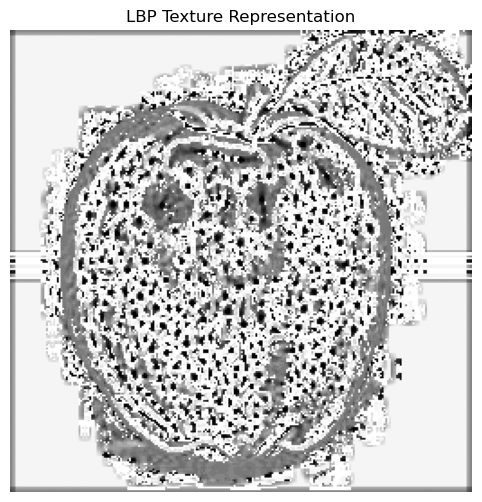

In [9]:
gray = cv2.cvtColor(
    images[0],
    cv2.COLOR_BGR2GRAY
)

lbp = local_binary_pattern(
    gray,
    LBP_POINTS,
    LBP_RADIUS,
    method="uniform"
)

plt.figure(figsize=(8, 6))

plt.imshow(
    lbp,
    cmap="gray"
)

plt.title(
    "LBP Texture Representation"
)

plt.axis("off")
plt.show()

In [10]:
from skimage.feature import graycomatrix, graycoprops

glcm_features = []

for image in images:

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # Convert 256 gray levels to 32 levels
    gray = (gray / 8).astype(
        np.uint8
    )

    glcm = graycomatrix(
        gray,
        distances=[1, 2, 3],
        angles=[
            0,
            np.pi / 4,
            np.pi / 2,
            3 * np.pi / 4
        ],
        levels=32,
        symmetric=True,
        normed=True
    )

    features = []

    properties = [
        "contrast",
        "dissimilarity",
        "homogeneity",
        "energy",
        "correlation",
        "ASM"
    ]

    for prop in properties:

        values = graycoprops(
            glcm,
            prop
        )

        features.extend(
            values.flatten()
        )

    glcm_features.append(
        features
    )

glcm_features = np.array(
    glcm_features,
    dtype=np.float32
)

print(
    "GLCM feature shape:",
    glcm_features.shape
)

GLCM feature shape: (2277, 72)


In [11]:
X = np.hstack(
    [
        sift_features,
        lbp_features,
        glcm_features
    ]
)

y = labels

print("SIFT features :", sift_features.shape)
print("LBP features  :", lbp_features.shape)
print("GLCM features :", glcm_features.shape)

print("--------------------------------")

print(
    "Final fused feature shape:",
    X.shape
)

SIFT features : (2277, 50)
LBP features  : (2277, 26)
GLCM features : (2277, 72)
--------------------------------
Final fused feature shape: (2277, 148)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 1821
Testing samples : 456


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Feature standardization completed.")

Feature standardization completed.


In [14]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=0.95,
    random_state=42
)

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)

print(
    "Original feature dimensions:",
    X_train.shape[1]
)

print(
    "PCA feature dimensions:",
    X_train_pca.shape[1]
)

print(
    "Variance retained:",
    round(
        pca.explained_variance_ratio_.sum() * 100,
        2
    ),
    "%"
)

Original feature dimensions: 148
PCA feature dimensions: 44
Variance retained: 95.23 %


In [15]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_pca,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test_pca
)

print("XGBoost training completed.")

XGBoost training completed.


In [16]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(
    X_train_pca,
    y_train
)

lgbm_pred = lgbm_model.predict(
    X_test_pca
)

print("LightGBM training completed.")

LightGBM training completed.


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_pca,
    y_train
)

rf_pred = rf_model.predict(
    X_test_pca
)

print("Random Forest training completed.")

Random Forest training completed.


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_pca,
    y_train
)

rf_pred = rf_model.predict(
    X_test_pca
)

print("Random Forest training completed.")

Random Forest training completed.


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print("\n==============================")
    print(name)
    print("==============================")

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-Score :", round(f1, 4))

    print("\nClassification Report:")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0
        )
    )

    return [
        name,
        accuracy,
        precision,
        recall,
        f1
    ]

In [25]:
results = []

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    )
)

results.append(
    evaluate_model(
        "LightGBM",
        y_test,
        lgbm_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)


XGBoost
Accuracy : 0.8575
Precision: 0.8587
Recall   : 0.8575
F1-Score : 0.8576

Classification Report:
               precision    recall  f1-score   support

        apple       0.88      0.84      0.86       241
custard apple       0.83      0.87      0.85       215

     accuracy                           0.86       456
    macro avg       0.86      0.86      0.86       456
 weighted avg       0.86      0.86      0.86       456


LightGBM
Accuracy : 0.8487
Precision: 0.8493
Recall   : 0.8487
F1-Score : 0.8488

Classification Report:
               precision    recall  f1-score   support

        apple       0.87      0.84      0.85       241
custard apple       0.83      0.86      0.84       215

     accuracy                           0.85       456
    macro avg       0.85      0.85      0.85       456
 weighted avg       0.85      0.85      0.85       456


Random Forest
Accuracy : 0.8399
Precision: 0.8405
Recall   : 0.8399
F1-Score : 0.84

Classification Report:
              

In [26]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Classifier",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

results_df

,Classifier,Accuracy,Precision,Recall,F1-Score
0,XGBoost,0.857456,0.858680,0.857456,0.857569
1,LightGBM,0.848684,0.849278,0.848684,0.848781
2,Random Forest,0.839912,0.840513,0.839912,0.840015


In [28]:
results = []

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    )
)

results.append(
    evaluate_model(
        "LightGBM",
        y_test,
        lgbm_pred
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)


XGBoost
Accuracy : 0.8575
Precision: 0.8587
Recall   : 0.8575
F1-Score : 0.8576

Classification Report:
               precision    recall  f1-score   support

        apple       0.88      0.84      0.86       241
custard apple       0.83      0.87      0.85       215

     accuracy                           0.86       456
    macro avg       0.86      0.86      0.86       456
 weighted avg       0.86      0.86      0.86       456


LightGBM
Accuracy : 0.8487
Precision: 0.8493
Recall   : 0.8487
F1-Score : 0.8488

Classification Report:
               precision    recall  f1-score   support

        apple       0.87      0.84      0.85       241
custard apple       0.83      0.86      0.84       215

     accuracy                           0.85       456
    macro avg       0.85      0.85      0.85       456
 weighted avg       0.85      0.85      0.85       456


Random Forest
Accuracy : 0.8399
Precision: 0.8405
Recall   : 0.8399
F1-Score : 0.84

Classification Report:
              

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

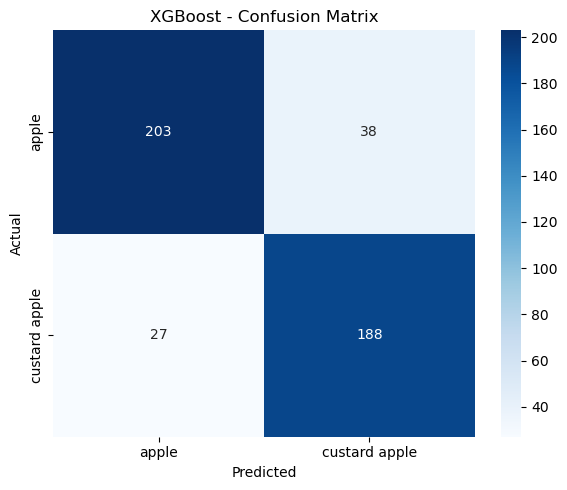

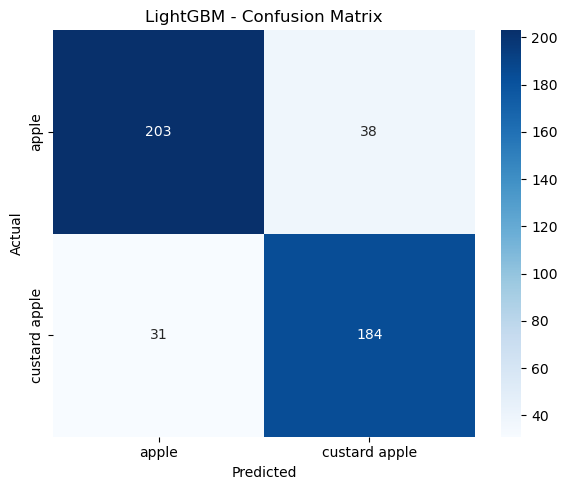

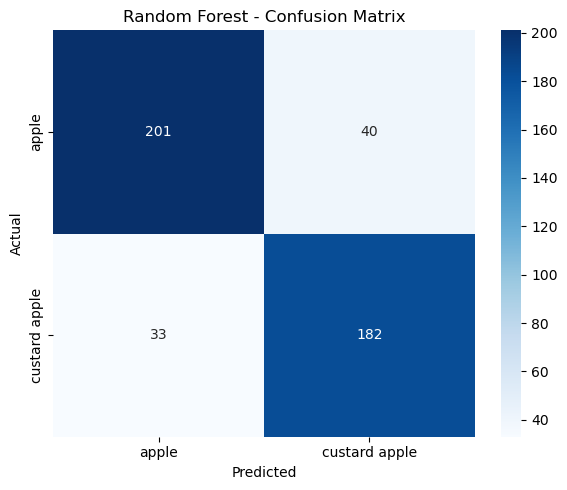

In [31]:
predictions = {
    "XGBoost": xgb_pred,
    "LightGBM": lgbm_pred,
    "Random Forest": rf_pred
}

for name, prediction in predictions.items():

    cm = confusion_matrix(
        y_test,
        prediction
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(
        f"{name} - Confusion Matrix"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

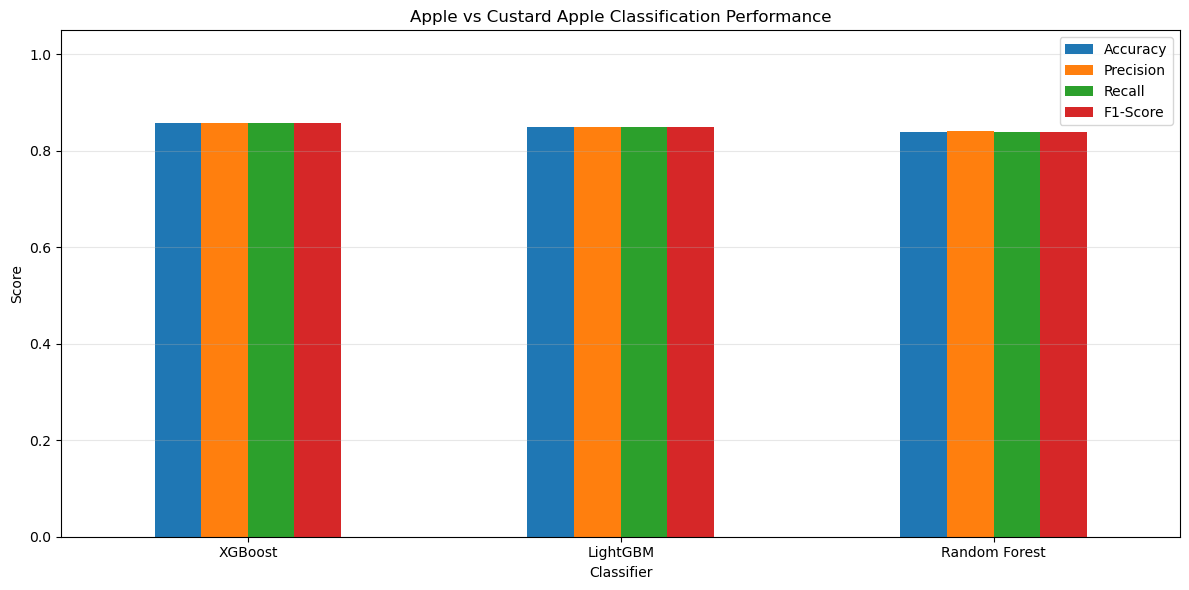

In [32]:
results_df.set_index(
    "Classifier"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Apple vs Custard Apple Classification Performance"
)

plt.ylabel("Score")

plt.ylim(
    0,
    1.05
)

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [33]:
best_index = results_df["F1-Score"].idxmax()

best_classifier = results_df.loc[
    best_index,
    "Classifier"
]

best_accuracy = results_df.loc[
    best_index,
    "Accuracy"
]

best_f1 = results_df.loc[
    best_index,
    "F1-Score"
]

print("====================================")
print("BEST PERFORMING CLASSIFIER")
print("====================================")

print(
    "Classifier:",
    best_classifier
)

print(
    "Accuracy:",
    round(best_accuracy, 4)
)

print(
    "F1-Score:",
    round(best_f1, 4)
)

BEST PERFORMING CLASSIFIER
Classifier: XGBoost
Accuracy: 0.8575
F1-Score: 0.8576


In [34]:
results_df.to_csv(
    "Apple_vs_Custard_Apple_Results.csv",
    index=False
)

print(
    "Results saved as:"
)

print(
    "Apple_vs_Custard_Apple_Results.csv"
)

Results saved as:
Apple_vs_Custard_Apple_Results.csv


In [35]:
# Final Classifier Comparison

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

predictions = {
    "XGBoost": xgb_pred,
    "LightGBM": lgbm_pred,
    "Random Forest": rf_pred
}

comparison = []

for name, prediction in predictions.items():

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        prediction,
        average="weighted",
        zero_division=0
    )

    comparison.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    comparison,
    columns=[
        "Classifier",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

# Display results
print("========================================")
print("CLASSIFIER COMPARISON")
print("========================================")

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

# Identify best classifier using F1-score
best_index = results_df["F1-Score"].idxmax()
best_classifier = results_df.loc[best_index, "Classifier"]

print("\n========================================")
print("BEST-PERFORMING CLASSIFIER")
print("========================================")
print("Classifier:", best_classifier)
print("Accuracy  :", round(results_df.loc[best_index, "Accuracy"], 4))
print("Precision :", round(results_df.loc[best_index, "Precision"], 4))
print("Recall    :", round(results_df.loc[best_index, "Recall"], 4))
print("F1-Score  :", round(results_df.loc[best_index, "F1-Score"], 4))

CLASSIFIER COMPARISON


,Classifier,Accuracy,Precision,Recall,F1-Score
0,XGBoost,0.8575,0.8587,0.8575,0.8576
1,LightGBM,0.8487,0.8493,0.8487,0.8488
2,Random Forest,0.8399,0.8405,0.8399,0.8400



BEST-PERFORMING CLASSIFIER
Classifier: XGBoost
Accuracy  : 0.8575
Precision : 0.8587
Recall    : 0.8575
F1-Score  : 0.8576
